In [1]:
import pandas as pd
import numpy as np 
import torch 

In [2]:
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
import numpy as np
import os
from numpy.polynomial import chebyshev
from scipy import interpolate


def background_subtraction(x_data, y_data, cheb_order = 5, std_mult = 10, tolerance = 1e-8):
    def exclude_outliers(x, y, fit_y, std_mult = 3):
        y_bs = y - fit_y
        mean = np.mean(y_bs)
        std = np.std(y_bs)
        outlier_mask = (y_bs < mean + std * std_mult) & (y_bs > mean - std * std_mult)
        x_data = x[outlier_mask]
        y_data = y[outlier_mask]
        return x_data, y_data

    def chebyshev_fit(x, *coeffs):
        # Use the first 3 Chebyshev polynomials of the first kind
        return sum(c * chebyshev.chebval(x, [0] * i + [1]) for i, c in enumerate(coeffs))

    y_data = y_data / np.max(y_data)
    
    x_data_background = x_data
    background = y_data
    fit_y = [0] * len(background)
    initial_guess = [0] * cheb_order
    counter = 0
    
    while abs(sum(fit_y - background)/len(fit_y)) > tolerance and counter < 20:
        popt, _ = optimize.curve_fit(chebyshev_fit, x_data_background, background, p0=initial_guess)
        fit_y = chebyshev_fit(x_data_background, *popt)
        x_data_background, background = exclude_outliers(x_data_background, background, fit_y, std_mult=3)
        fit_y = chebyshev_fit(x_data_background, *popt)
        counter += 1
    
    if counter == 20:
        print("This model may perform poorly on data with a complicated background")
        
    popt, _ = optimize.curve_fit(chebyshev_fit, x_data_background, background, p0=initial_guess)

    # Generate fitted y values
    fit_y = chebyshev_fit(x_data, *popt)

    # Subtract fitted y values from data
    y_data = y_data - fit_y

    return y_data

powder_file_dir = "/home/gridsan/groups/Freedman_CDVAE/expt_data/good/"
#powder_files = os.listdir(powder_file_dir)
powder_files = ['Bi_aba_vbi_ballmill_nsls_15_4.xyd', 'Si_bcb_si_glovebox.xyd', 'Pb_i_86_1_nipbelementalcontrol.xyd', 'PdBi2_ear_i_0fillin_pdbi2_cathy.xyd', 'FeO_feo_2.001.xyd', 'FeO_feo_2.003.xyd', 'V2O5_rak_v2o5_box.xyd', 'Ni_adt_2_12_2_dark_ni_sn.xyd', 'Bi_aba_2_147_bt_febi_saltmeta_redo.xyd', 'V2O5_rak_v2o5_air.xyd', 'Fe_2021_01_05_fe_byadt.xyd', 'NiSb_adt_2_12_4_purple_ni_sb.xyd', 'FeO_feo_2.002.xyd', 'V2O5_aba_v2so5_sm.xyd', 'NiPb_i_86_1liberatedxtalstake5.xyd', 'Bi_aba_febi_ballmilled_1_20.xyd', 'Bi_aba_febi_ballmilled_11_20_reedo.xyd', 'Bi_aba_febi_ballmill_beamtime_20_3.xyd', 'NiBi_bcb_i_1_1_nibi.xyd', 'InBi_ear_i_0fillin_inbi.xyd', 'In2Bi_ear_i_0fillin_in2bi_040221.xyd', 'NiBi3_ear_i_055_nibi3.xyd', 'InSb_ear_i_0fillin_in2sbbi.xyd', 'FeO_feo_short.xyd', 'Ba2ZrS4_aba_2_117_ba2zrs4_check.xyd', 'InBi_ear_i_0fillin_inbi_032821.xyd', 'Bi_aba_febi_ballmilled_11_20.xyd', 'BaBi3_adt_i_143_1_babi.xyd', 'Ti4CoBi2_20210126_ckb_i_ti4cobi2_samplei.xyd', 'Bi_aba_2_147_bt_febi_ballmilled_redo3.xyd', 'MnBi_aba_smc_mnbi_xstal.xyd', 'PdBi2_ear_i_056_pdbi2.xyd', 'KBi2_aba_2_127_kbi2.xyd', 'Bi_aba_2_147_mnbi_ballmill.xyd', 'Bi_aba_febi_ballmill_1.xyd', 'Bi_aba_2_147_rubi_ballmilled.xyd']
print(powder_files)
print(len(powder_files))

['Bi_aba_vbi_ballmill_nsls_15_4.xyd', 'Si_bcb_si_glovebox.xyd', 'Pb_i_86_1_nipbelementalcontrol.xyd', 'PdBi2_ear_i_0fillin_pdbi2_cathy.xyd', 'FeO_feo_2.001.xyd', 'FeO_feo_2.003.xyd', 'V2O5_rak_v2o5_box.xyd', 'Ni_adt_2_12_2_dark_ni_sn.xyd', 'Bi_aba_2_147_bt_febi_saltmeta_redo.xyd', 'V2O5_rak_v2o5_air.xyd', 'Fe_2021_01_05_fe_byadt.xyd', 'NiSb_adt_2_12_4_purple_ni_sb.xyd', 'FeO_feo_2.002.xyd', 'V2O5_aba_v2so5_sm.xyd', 'NiPb_i_86_1liberatedxtalstake5.xyd', 'Bi_aba_febi_ballmilled_1_20.xyd', 'Bi_aba_febi_ballmilled_11_20_reedo.xyd', 'Bi_aba_febi_ballmill_beamtime_20_3.xyd', 'NiBi_bcb_i_1_1_nibi.xyd', 'InBi_ear_i_0fillin_inbi.xyd', 'In2Bi_ear_i_0fillin_in2bi_040221.xyd', 'NiBi3_ear_i_055_nibi3.xyd', 'InSb_ear_i_0fillin_in2sbbi.xyd', 'FeO_feo_short.xyd', 'Ba2ZrS4_aba_2_117_ba2zrs4_check.xyd', 'InBi_ear_i_0fillin_inbi_032821.xyd', 'Bi_aba_febi_ballmilled_11_20.xyd', 'BaBi3_adt_i_143_1_babi.xyd', 'Ti4CoBi2_20210126_ckb_i_ti4cobi2_samplei.xyd', 'Bi_aba_2_147_bt_febi_ballmilled_redo3.xyd', 'MnBi_

In [3]:
def iterative_spline_background_subtraction(x_data, y_data, s=0.0001, k=3, iterations=10):
    for _ in range(iterations):
        print('hi')
        spline = interpolate.UnivariateSpline(x_data, y_data, k=k, s=s)
        print('by')
        spline_fit = spline(x_data)
        # Identify points above the spline (potential signal) and only keep points below
        y_data = np.minimum(y_data, spline_fit)
    
    # Final spline fit on the adjusted data
    final_spline = interpolate.UnivariateSpline(x_data, y_data, k=k, s=s)
    background = final_spline(x_data)

    # Subtract the background
    subtracted_signal = original_y_data - background

    return subtracted_signal, background


In [24]:
def rolling_median_baseline_subtraction(x_data, y_data, window_size):
    """
    Subtract baseline using a rolling median.

    :param x_data: Array of x-values (e.g., 2-theta in XRD)
    :param y_data: Array of y-values (intensity)
    :param window_size: Size of the rolling window for median calculation
    :return: y-values after baseline subtraction
    """
    
    # Calculate the rolling median
    rolling_median = pd.Series(y_data).rolling(window=window_size, min_periods=1, center=True).median()

    # Subtract the baseline (rolling median) from the original y data
    baseline_subtracted = y_data - rolling_median
    
    return baseline_subtracted, rolling_median

In [26]:
def rolling_median_baseline_subtraction(x_data, y_data, window_size, std_multiplier=3):
    """
    Subtract baseline using a rolling median with outlier exclusion.

    :param x_data: Array of x-values (e.g., 2-theta in XRD)
    :param y_data: Array of y-values (intensity)
    :param window_size: Size of the rolling window for median calculation
    :param std_multiplier: Multiplier for standard deviation to determine outliers
    :return: y-values after baseline subtraction
    """

    def calculate_rolling_median(y_data, window_size):
        return pd.Series(y_data).rolling(window=window_size, min_periods=1, center=True).median()

    def detect_outliers(median_series, y_data, std_multiplier):
        difference = np.abs(y_data - median_series)
        threshold = std_multiplier * np.std(difference)
        return difference < threshold

    rolling_median = calculate_rolling_median(y_data, window_size)
    mask = detect_outliers(rolling_median, y_data, std_multiplier)

    # Recalculate the rolling median excluding identified outliers
    filtered_y_data = np.where(mask, y_data, np.nan)
    rolling_median = calculate_rolling_median(filtered_y_data, window_size)

    # Subtract the recalculated baseline (rolling median) from the original y data
    baseline_subtracted = y_data - rolling_median

    return baseline_subtracted, rolling_median

Bi_aba_vbi_ballmill_nsls_15_4.xyd


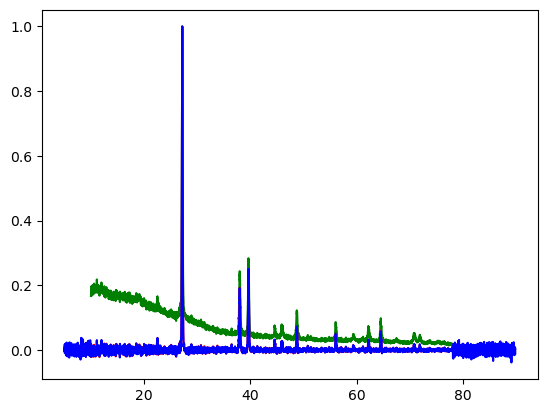

Si_bcb_si_glovebox.xyd


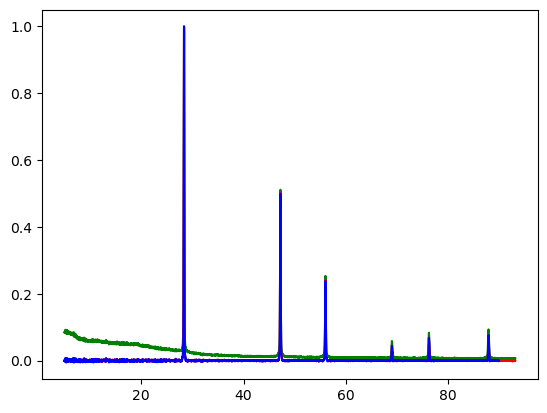

Pb_i_86_1_nipbelementalcontrol.xyd


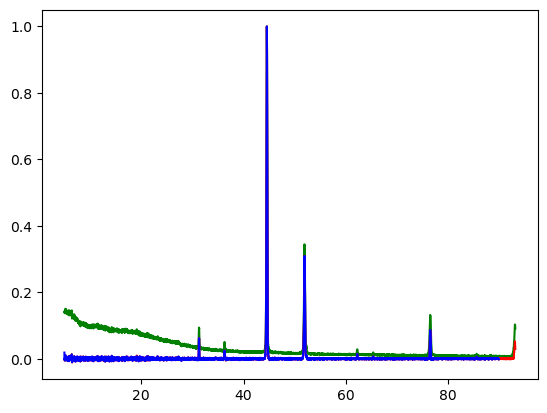

PdBi2_ear_i_0fillin_pdbi2_cathy.xyd


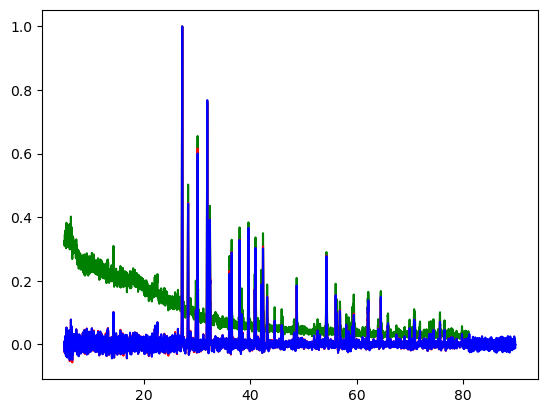

FeO_feo_2.001.xyd


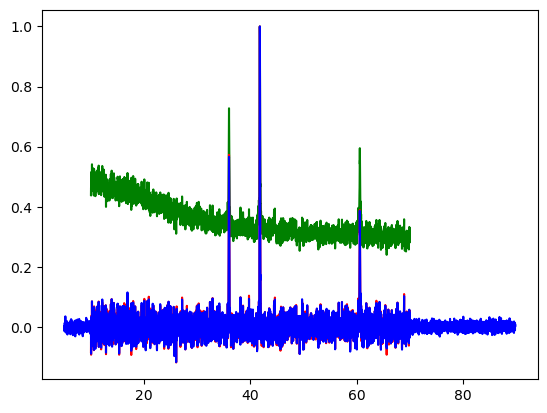

FeO_feo_2.003.xyd


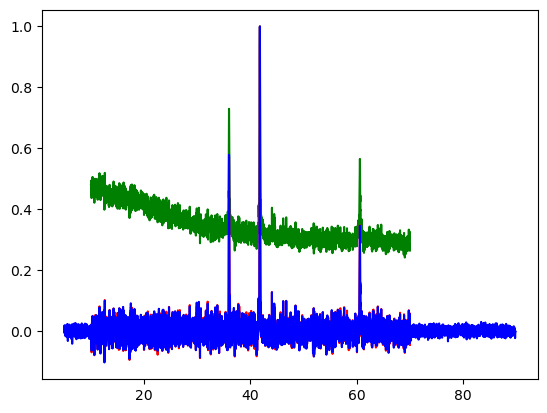

V2O5_rak_v2o5_box.xyd


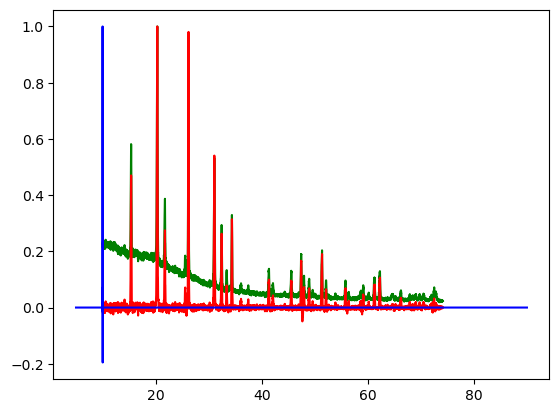

Ni_adt_2_12_2_dark_ni_sn.xyd


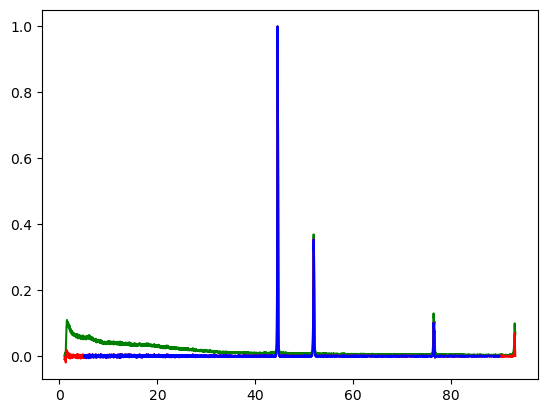

Bi_aba_2_147_bt_febi_saltmeta_redo.xyd


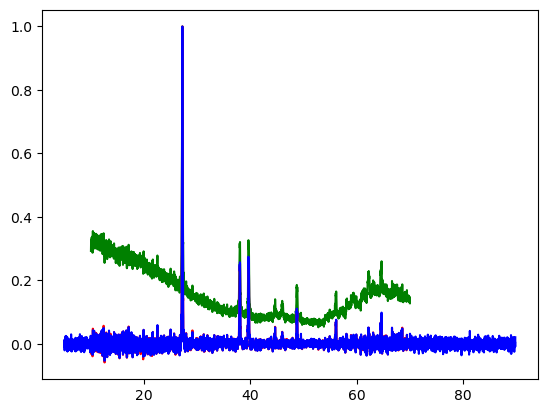

V2O5_rak_v2o5_air.xyd


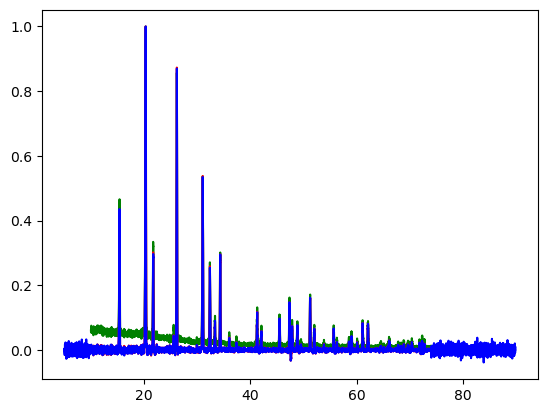

Fe_2021_01_05_fe_byadt.xyd


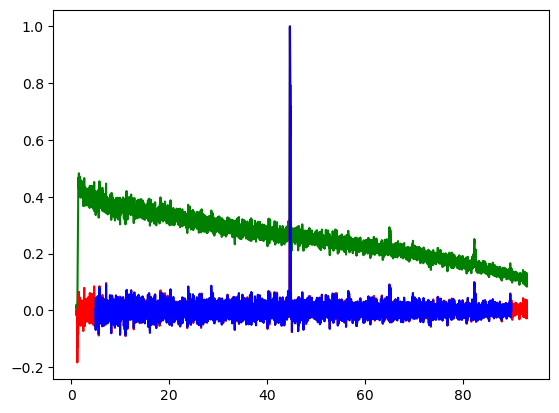

NiSb_adt_2_12_4_purple_ni_sb.xyd


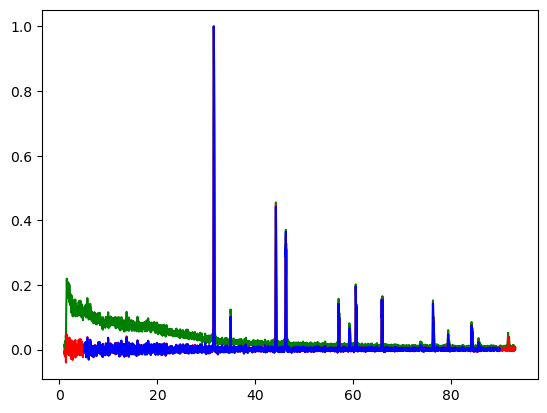

FeO_feo_2.002.xyd


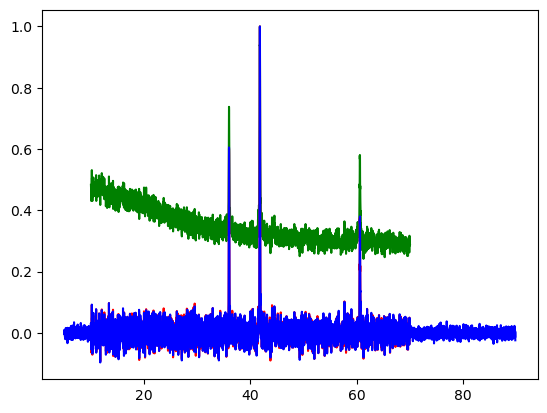

V2O5_aba_v2so5_sm.xyd


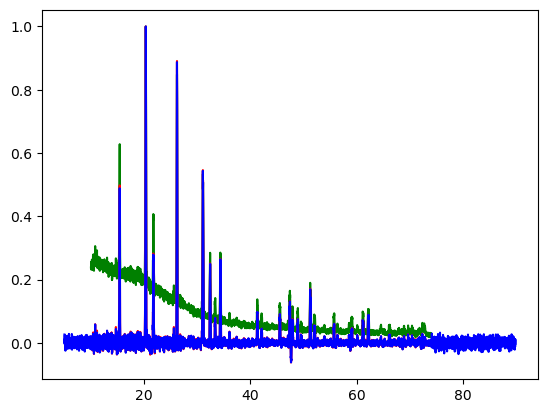

NiPb_i_86_1liberatedxtalstake5.xyd


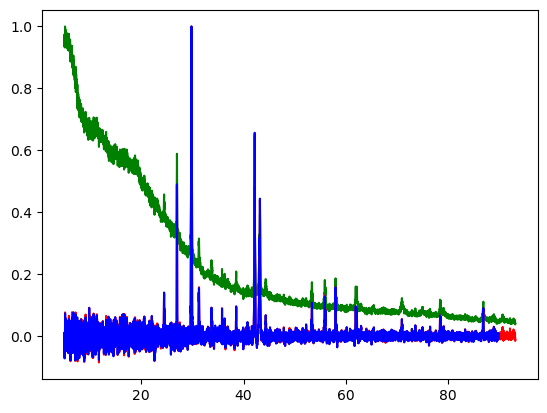

Bi_aba_febi_ballmilled_1_20.xyd


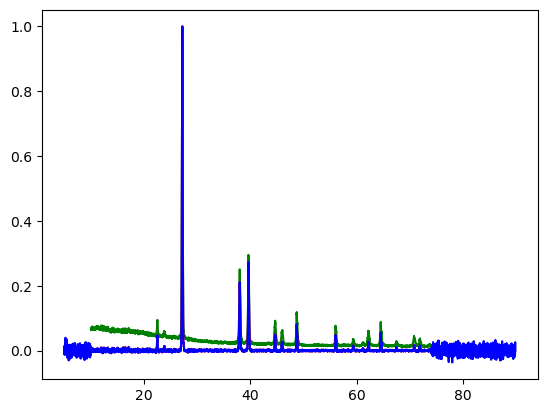

Bi_aba_febi_ballmilled_11_20_reedo.xyd


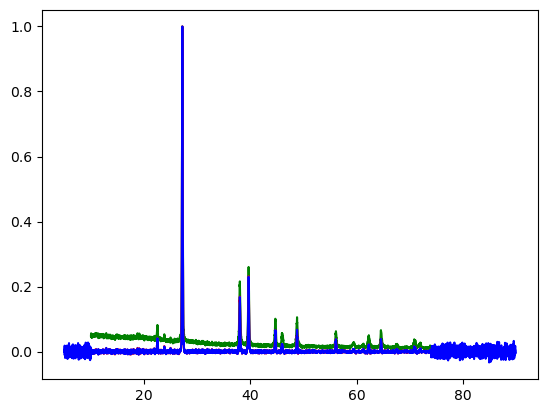

Bi_aba_febi_ballmill_beamtime_20_3.xyd


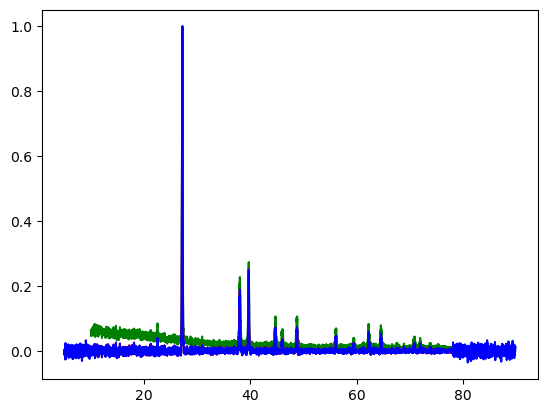

NiBi_bcb_i_1_1_nibi.xyd


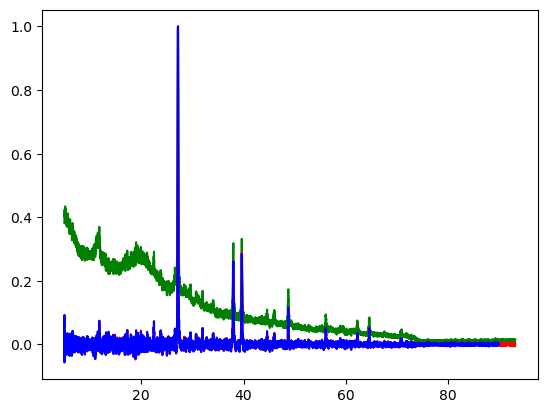

InBi_ear_i_0fillin_inbi.xyd


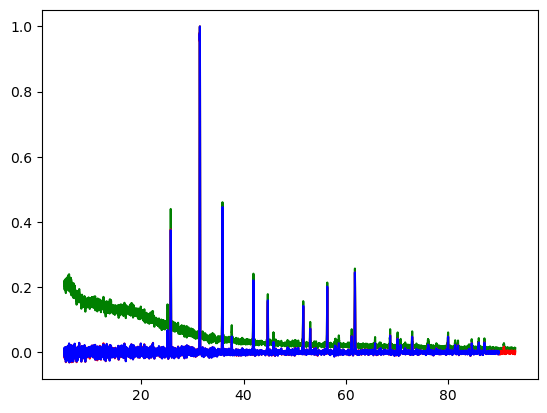

In2Bi_ear_i_0fillin_in2bi_040221.xyd


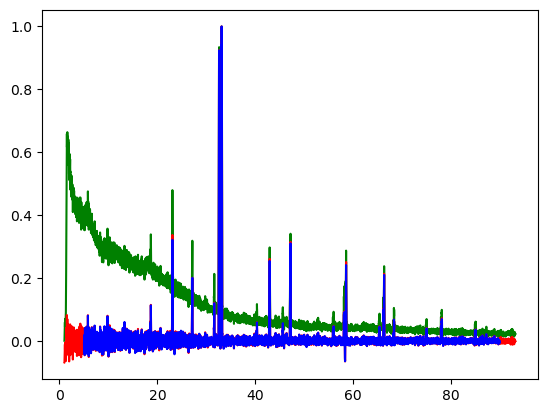

NiBi3_ear_i_055_nibi3.xyd


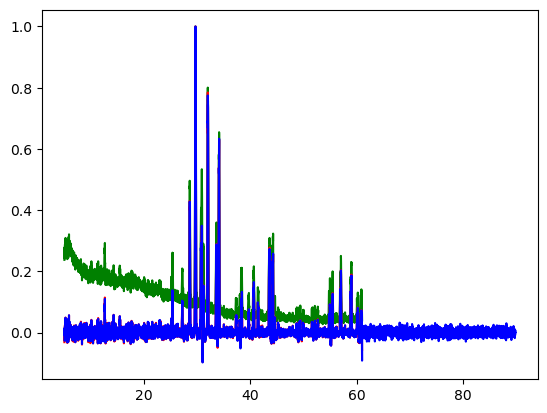

InSb_ear_i_0fillin_in2sbbi.xyd


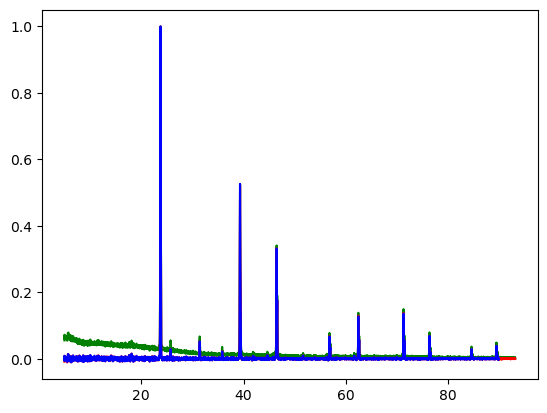

FeO_feo_short.xyd


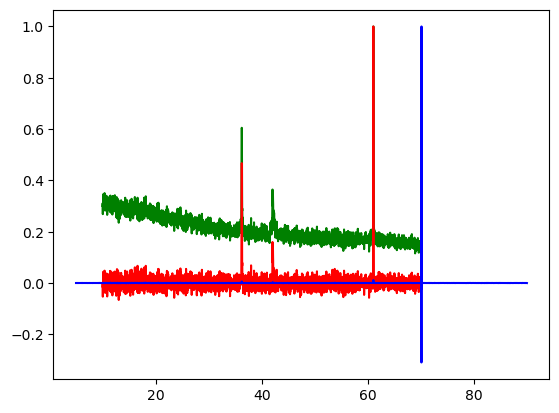

Ba2ZrS4_aba_2_117_ba2zrs4_check.xyd


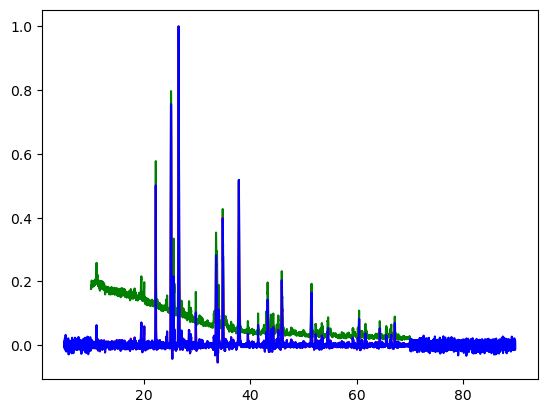

InBi_ear_i_0fillin_inbi_032821.xyd


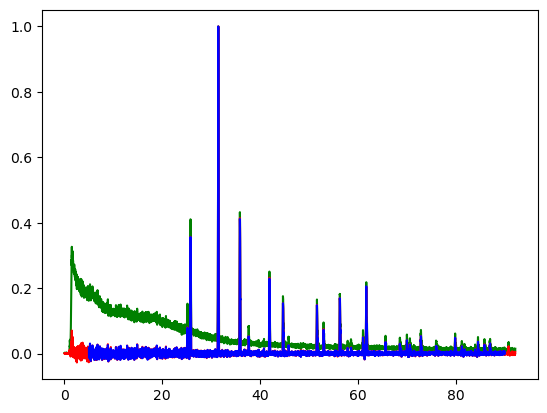

Bi_aba_febi_ballmilled_11_20.xyd


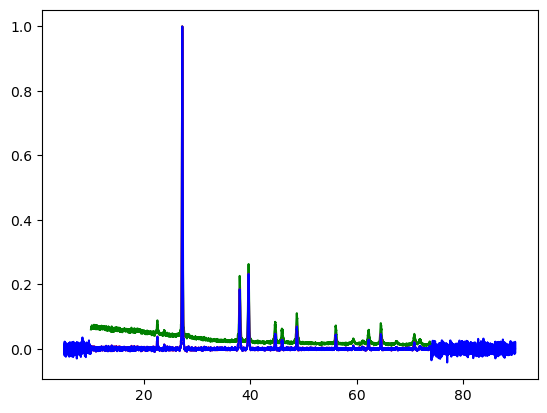

BaBi3_adt_i_143_1_babi.xyd


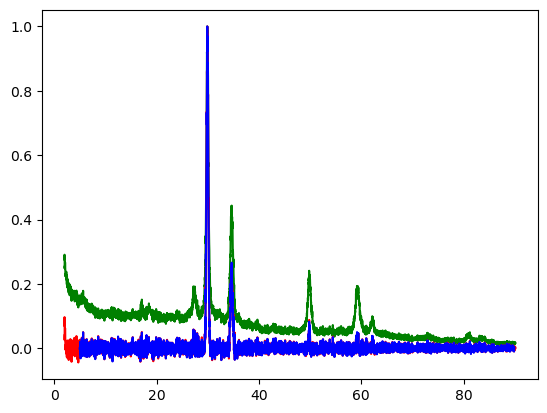

Ti4CoBi2_20210126_ckb_i_ti4cobi2_samplei.xyd


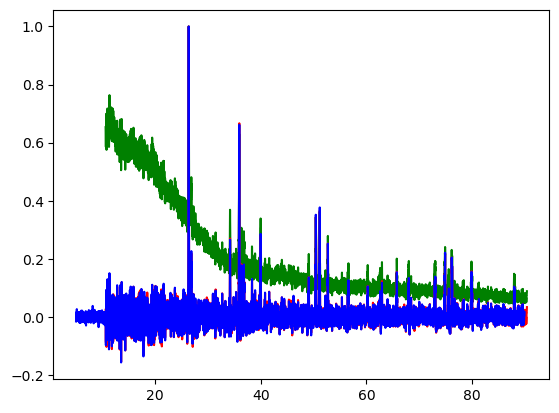

Bi_aba_2_147_bt_febi_ballmilled_redo3.xyd


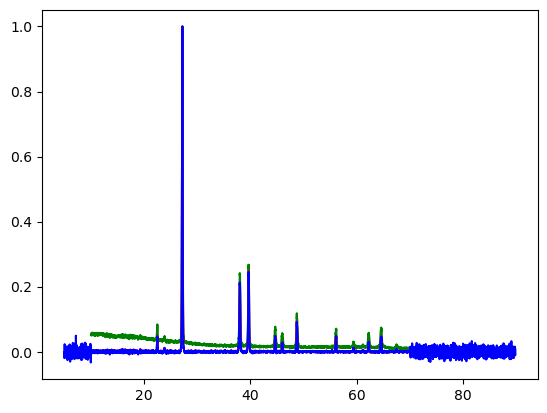

MnBi_aba_smc_mnbi_xstal.xyd


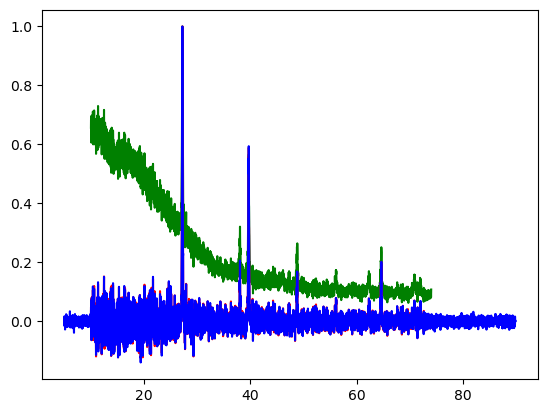

PdBi2_ear_i_056_pdbi2.xyd


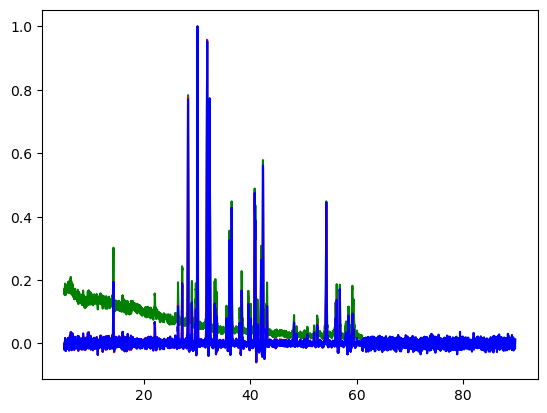

KBi2_aba_2_127_kbi2.xyd


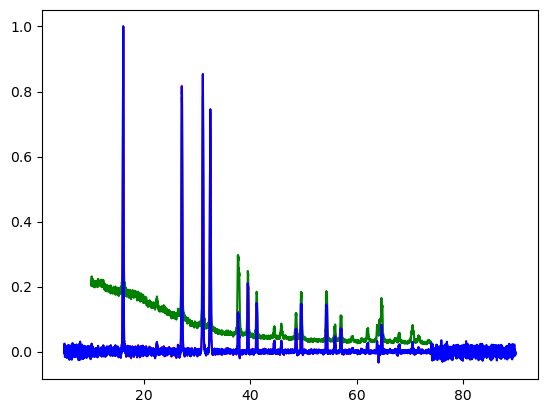

Bi_aba_2_147_mnbi_ballmill.xyd


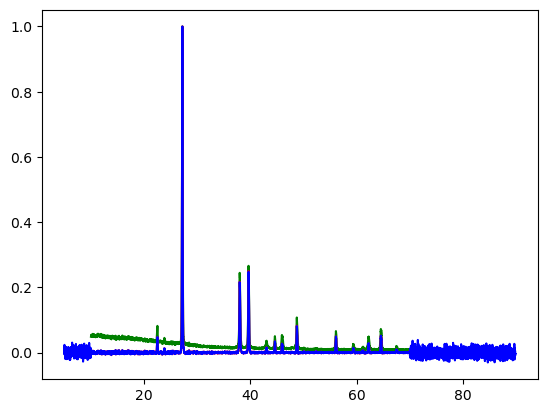

Bi_aba_febi_ballmill_1.xyd


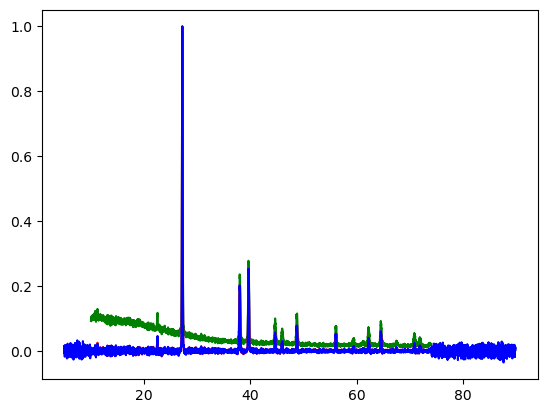

Bi_aba_2_147_rubi_ballmilled.xyd


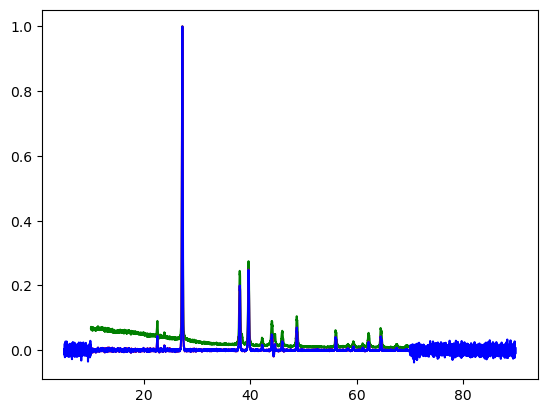

In [43]:
powder_data_list = []
for file in powder_files:
    if file.endswith(".xyd"):
        print(file)
        data = pd.read_csv(powder_file_dir + file, sep='\s+', header=None, names=['x', 'y', 'd'])
        x_data = np.array(data['x'])
        y_data = np.array(data['y'])
        
        plt.plot(x_data, y_data / np.max(y_data), color = 'green')
        y_data, _ = rolling_median_baseline_subtraction(x_data, y_data, window_size = 50)

        plt.plot(x_data, y_data / np.max(y_data), color = 'red')
        my_range = np.linspace(5, 89.9, num = 8500)
        
        smooth_data = interpolate.UnivariateSpline(x_data, y_data, k = 3, s = 1)

        #find the min and max x values 
        min_x = min(x_data)
        max_x = max(x_data)

        #initialize results as np zeros in the shape of my_range
        results = np.random.randn(len(my_range)) * 0.01 * np.max(y_data)

        #use smooth data to set the values of results corresponding to the values in my_range in
        #between the min and max x values
        for i in range(len(my_range)):
            if my_range[i] > min_x and my_range[i] < max_x:
                results[i] = smooth_data(my_range[i])
        new_y_data = results
        
        #last step is normalize
        
        new_y_data = new_y_data/np.max(new_y_data)
        
        plt.plot(my_range, new_y_data, color = 'blue')
        plt.show()
        plt.close()
        
        powder_data_list.append(new_y_data)

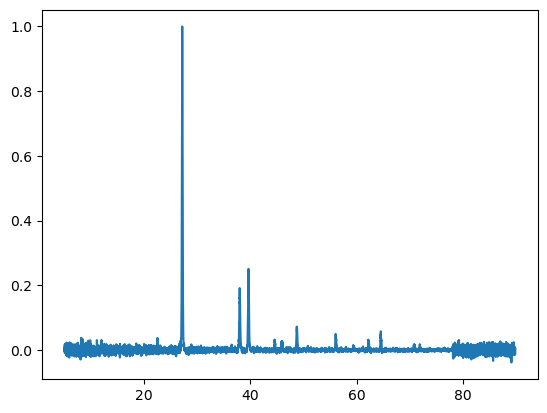

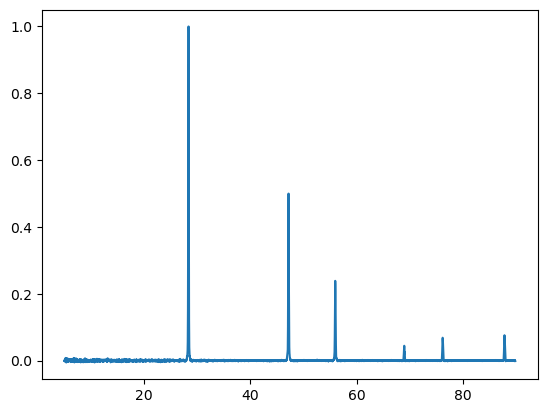

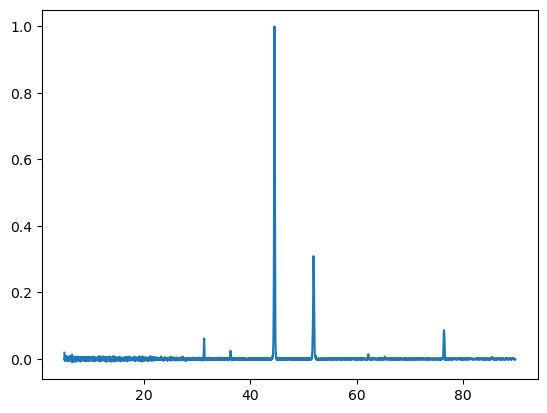

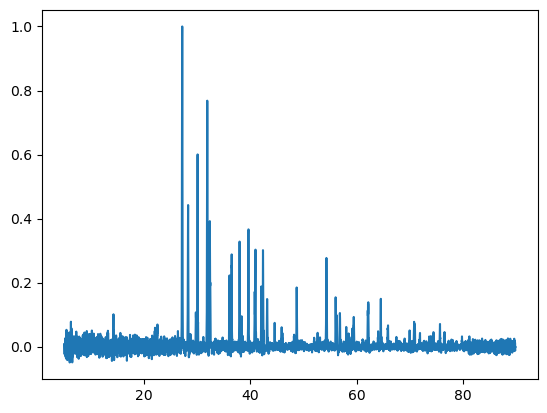

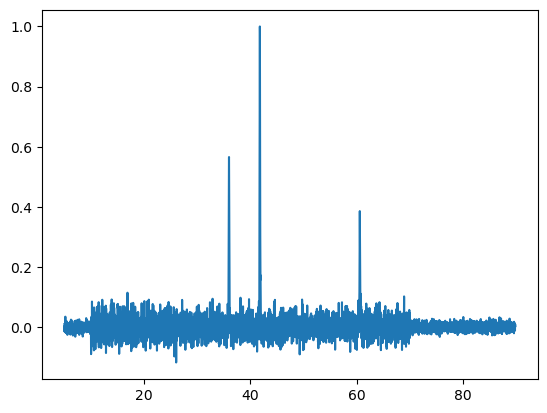

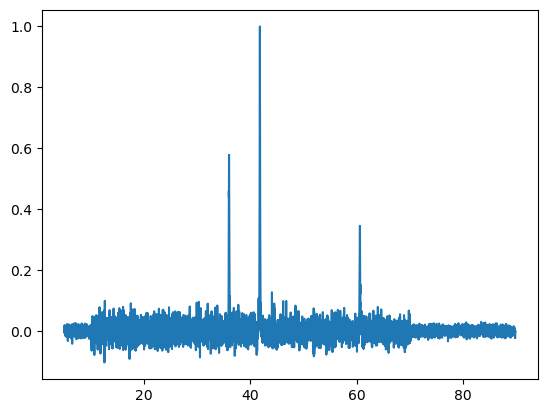

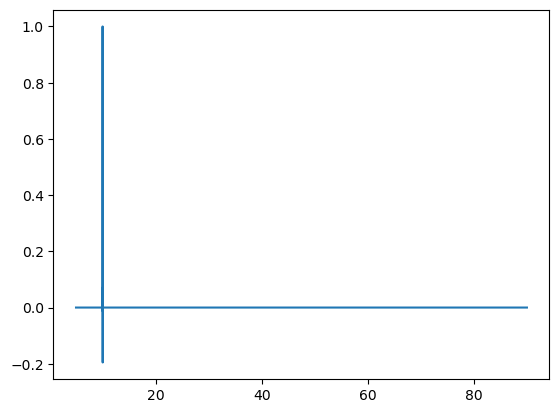

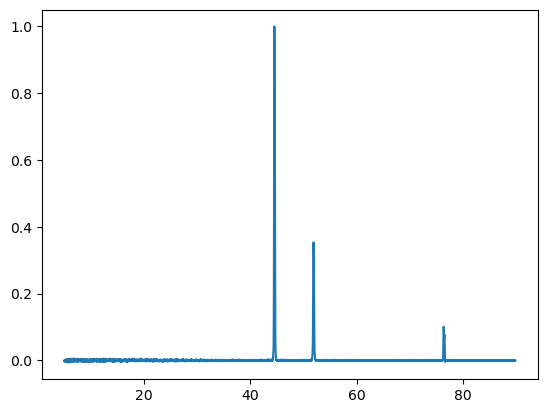

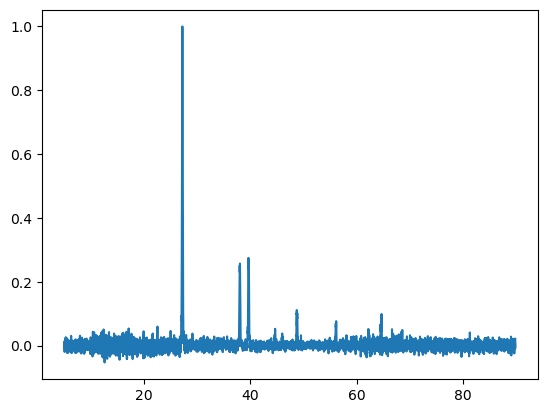

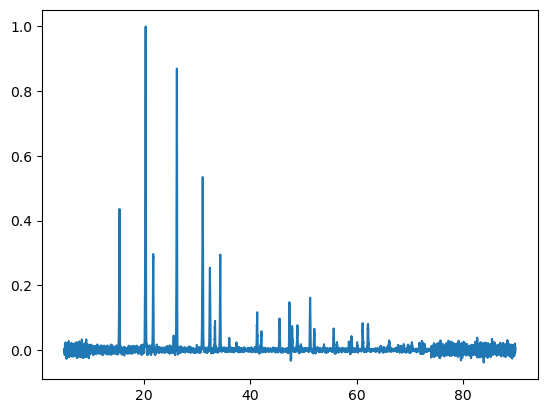

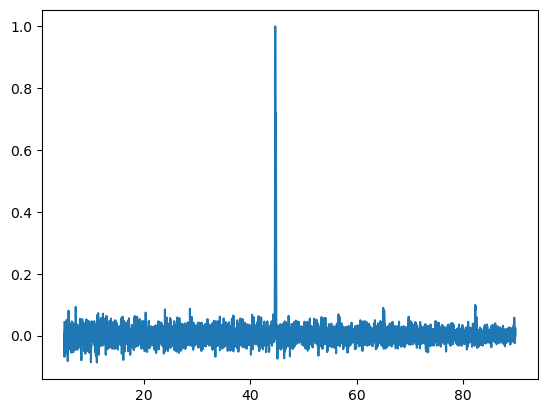

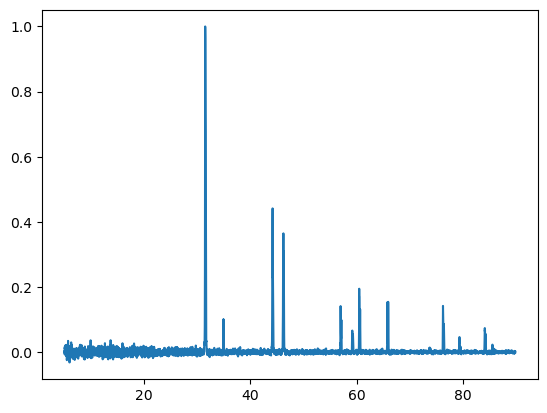

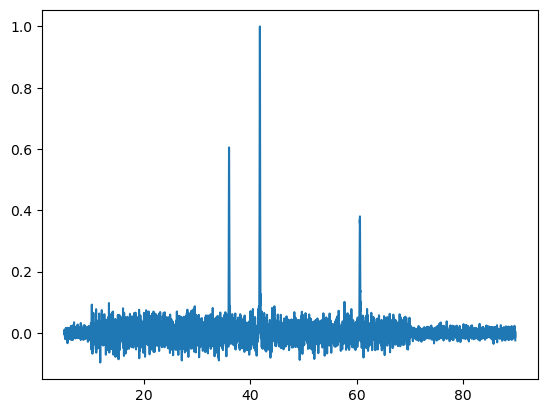

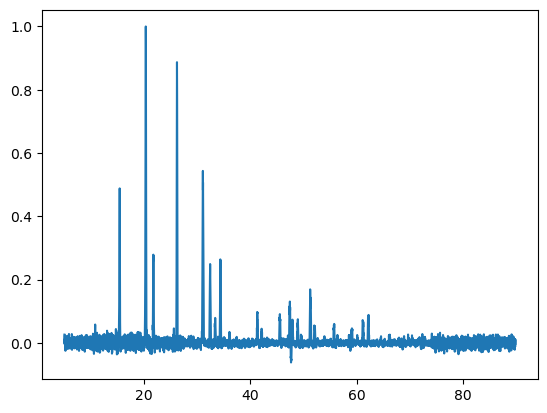

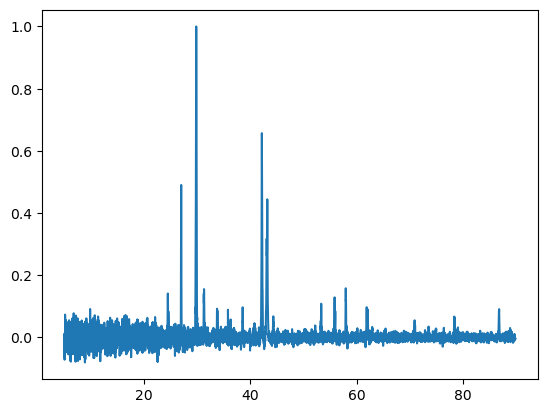

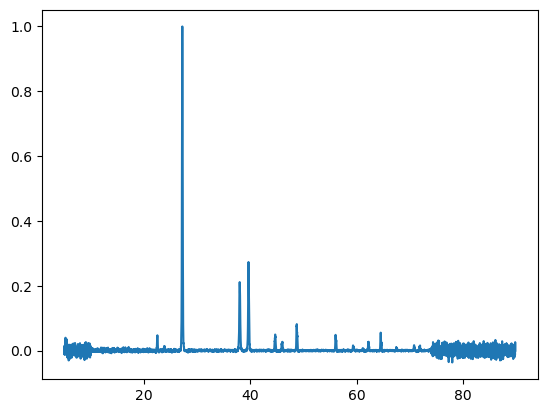

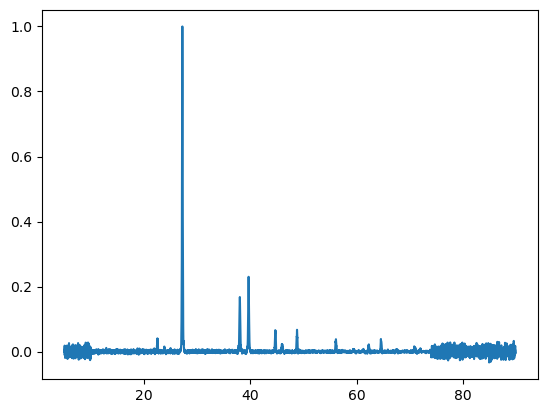

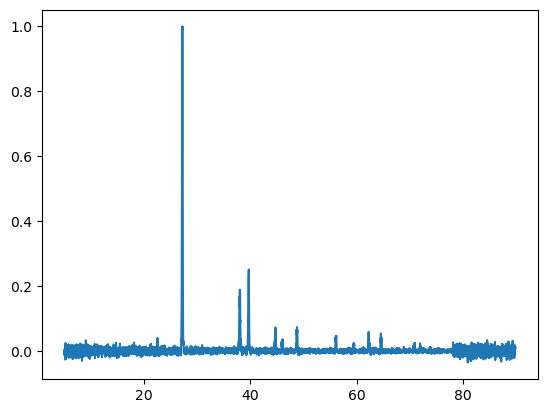

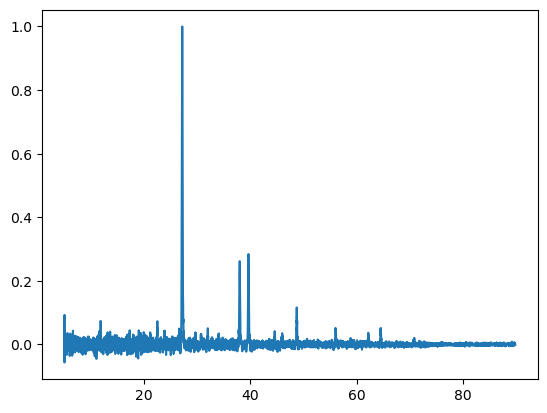

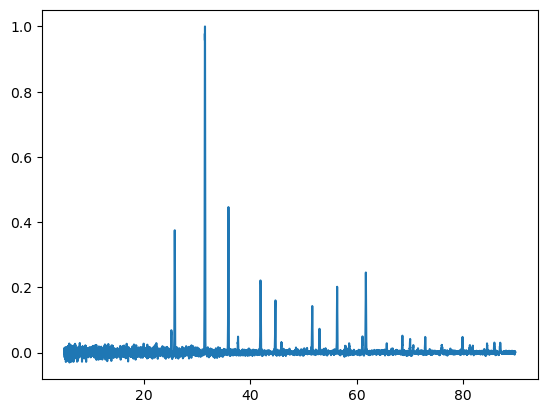

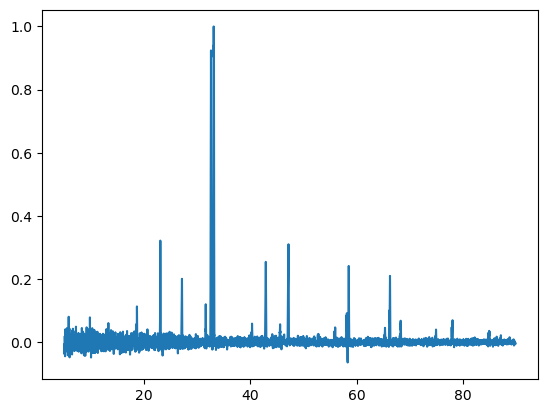

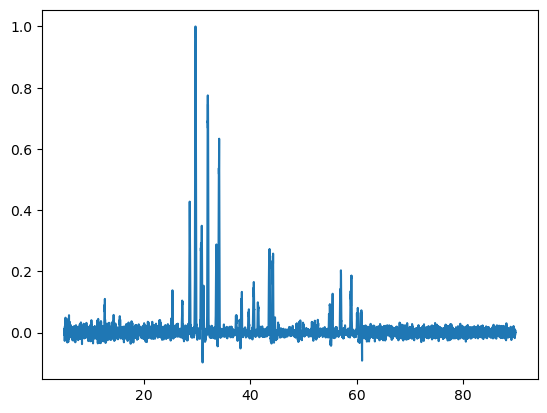

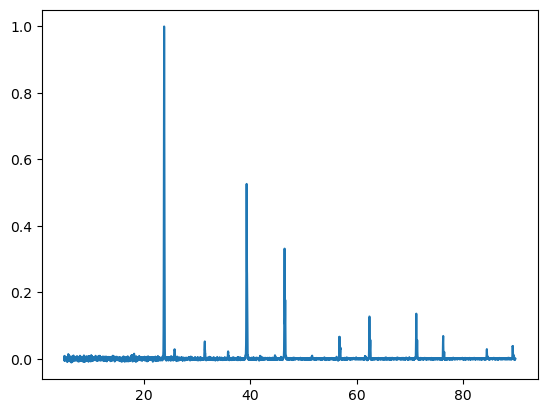

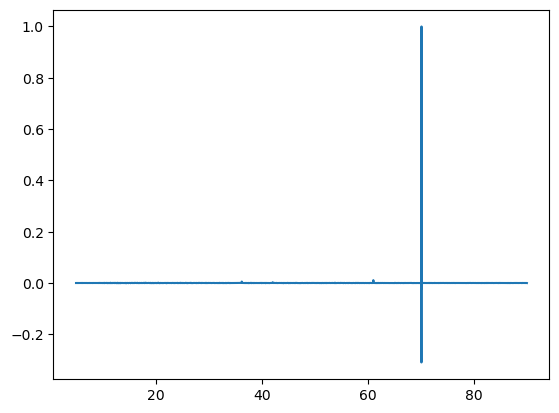

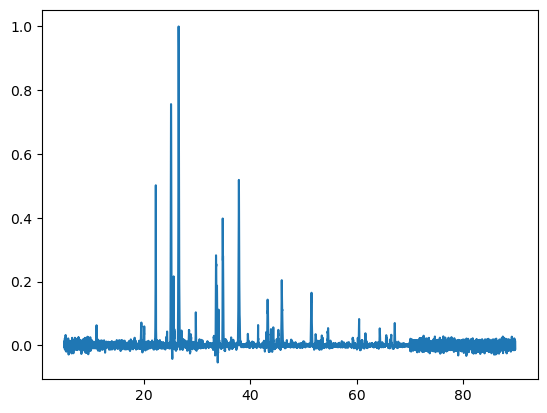

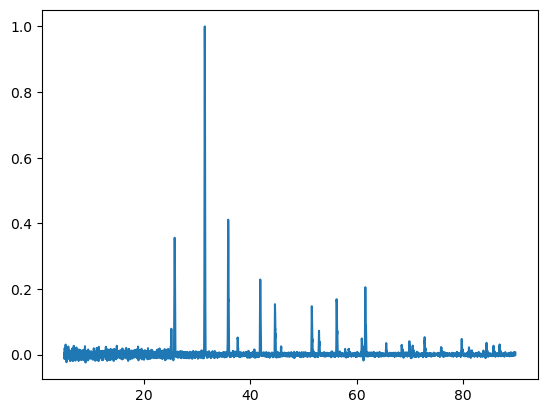

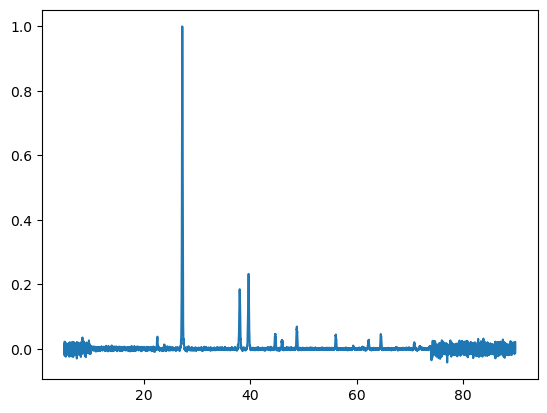

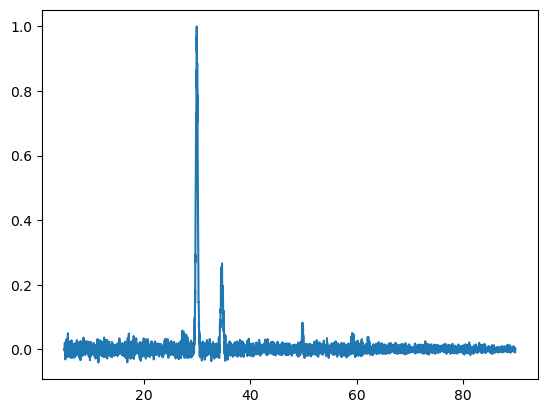

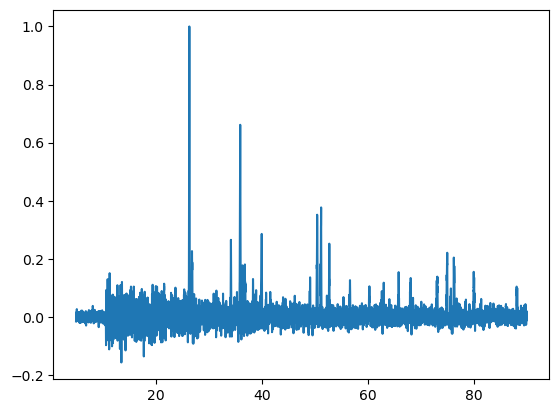

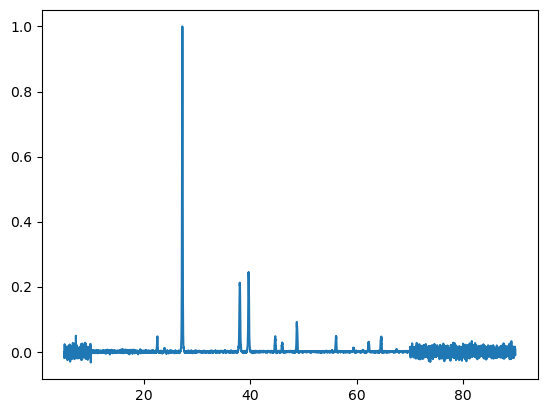

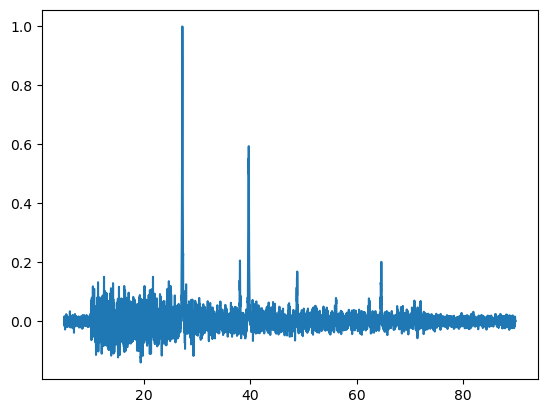

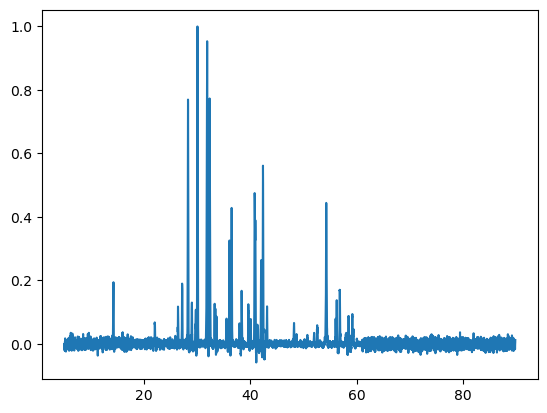

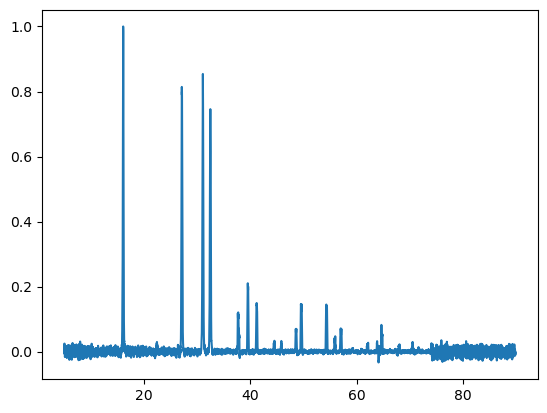

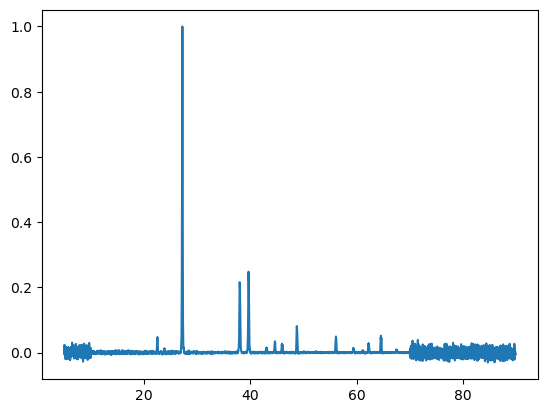

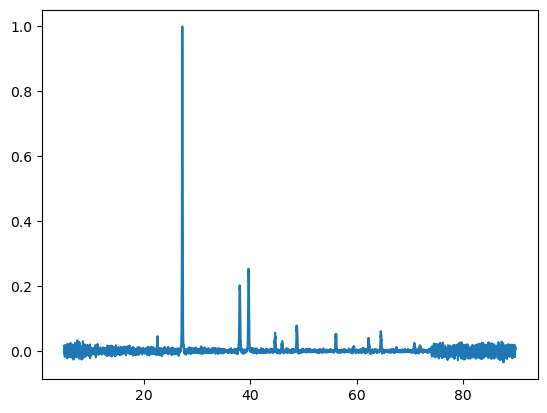

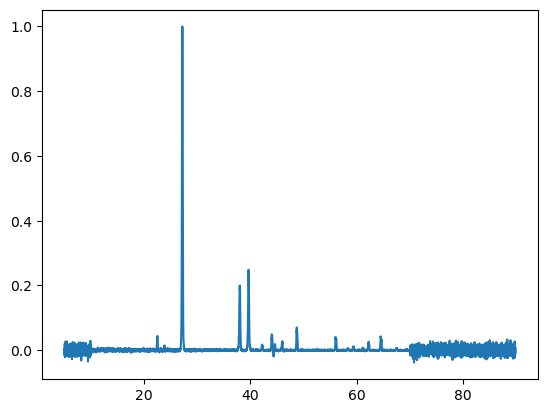

In [52]:
for power_data in powder_data_list:
    plt.plot(my_range, power_data)
    plt.show()

In [44]:
len(powder_data_list)

36

In [45]:
powder_data_dict = {}
for index, entry in enumerate(powder_data_list): 
    powder_data_dict[powder_files[index]] = entry

In [46]:
powder_data_dict

{'Bi_aba_vbi_ballmill_nsls_15_4.xyd': array([ 0.00683766,  0.00591668, -0.00428859, ..., -0.00574149,
        -0.00300134, -0.0103814 ]),
 'Si_bcb_si_glovebox.xyd': array([-0.0007578 ,  0.00142841,  0.00205048, ..., -0.00061261,
        -0.00133244, -0.00143041]),
 'Pb_i_86_1_nipbelementalcontrol.xyd': array([ 1.87958130e-02,  7.78314914e-05,  2.83298270e-04, ...,
        -8.03909855e-05, -5.70091900e-04, -8.40865136e-04]),
 'PdBi2_ear_i_0fillin_pdbi2_cathy.xyd': array([ 0.00738554, -0.00672925, -0.00031352, ..., -0.00341899,
         0.00119866, -0.01010916]),
 'FeO_feo_2.001.xyd': array([ 0.01072593, -0.01397729, -0.00594052, ...,  0.00799147,
         0.00644772,  0.00469328]),
 'FeO_feo_2.003.xyd': array([-0.00141857,  0.00437456, -0.00597187, ..., -0.01050247,
         0.00124467, -0.00027219]),
 'V2O5_rak_v2o5_box.xyd': array([ 9.16958636e-07, -1.64495397e-06,  7.91668109e-07, ...,
        -1.03242915e-06,  7.83371108e-07, -1.27560507e-06]),
 'Ni_adt_2_12_2_dark_ni_sn.xyd': array

In [47]:
curated_list = [powder_data_dict['V2O5_aba_v2so5_sm.xyd'],
                powder_data_dict['V2O5_aba_v2so5_sm.xyd'],
                powder_data_dict['InBi_ear_i_0fillin_inbi.xyd'],
                powder_data_dict['V2O5_aba_v2so5_sm.xyd'],
                powder_data_dict['Si_bcb_si_glovebox.xyd'],
                powder_data_dict['V2O5_aba_v2so5_sm.xyd'],
                powder_data_dict['In2Bi_ear_i_0fillin_in2bi_040221.xyd'],
                powder_data_dict['NiSb_adt_2_12_4_purple_ni_sb.xyd'],
                powder_data_dict['FeO_feo_2.002.xyd'],
                powder_data_dict['Pb_i_86_1_nipbelementalcontrol.xyd'],
                powder_data_dict['V2O5_aba_v2so5_sm.xyd'],
                powder_data_dict['FeO_feo_2.002.xyd'],
                powder_data_dict['FeO_feo_2.002.xyd'],
                powder_data_dict['V2O5_aba_v2so5_sm.xyd'],
                powder_data_dict['V2O5_aba_v2so5_sm.xyd']]

In [48]:
len(curated_list)

15

In [40]:
#save as a torch file 
torch.save(curated_list, "/home/gridsan/tmackey/cdvae/scripts/1-05-2024_experimental_data/selected_freedman_experiments.pt")

In [ ]:
#load in the training dataframe to make sure none of the experimental compounds are in there 
train_df = pd.read_csv("/home/gridsan/tmackey/cdvae/data/mp_20/train.csv")

cif_dir = "/home/gridsan/tmackey/CIFs_good_patterns/"

from pymatgen.core.structure import Structure
import os

# Directory containing the CIF files
cif_dir = "/home/gridsan/tmackey/CIFs_good_patterns/"

# List to store pymatgen crystal objects
crystal_objects = []

# Looping through each file in the directory
for filename in os.listdir(cif_dir):
    if filename.endswith(".cif"):
        file_path = os.path.join(cif_dir, filename)
        try:
            # Create pymatgen crystal object and add it to the list
            crystal = Structure.from_file(file_path)
            crystal_objects.append(crystal)
        except Exception as e:
            print(f"Error processing {filename}: {e}")



import ast

train_df['atomic_numbers'] = train_df['atomic_numbers'].apply(ast.literal_eval)

train_df['atomic_numbers'] = train_df['atomic_numbers'].apply(sorted)

elements_atomic_numbers = []

for crystal in crystal_objects:
    # List for atomic numbers in the current crystal
    atomic_numbers = []

    for site in crystal:
        # Get the atomic number and add it to the list
        atomic_number = site.specie.number
        atomic_numbers.append(atomic_number)

    # Add the list of atomic numbers to the master list
    elements_atomic_numbers.append(atomic_numbers)


elements_atomic_numbers = [sorted(lillist) for lillist in elements_atomic_numbers]

# Assuming train_df is your DataFrame and elements_atomic_numbers is the list of lists

# Create a new column to store the result of the check
train_df['in_elements_atomic_numbers'] = train_df['atomic_numbers'].apply(
    lambda x: x in elements_atomic_numbers
)

# Now, train_df has an additional column 'in_elements_atomic_numbers' 
# with True or False depending on whether the entry in 'atomic_numbers' 
# was found in elements_atomic_numbers

#load in the training pseudo-voights 
training_pseudo_voights = torch.load("/home/gridsan/tmackey/cdvae/data/mp_20/train_pv_xrd.pt")

experimental_crossover = train_df[train_df['in_elements_atomic_numbers'] == True]

#training pseudo voights 
simulated_pvs = {training_pseudo_voights[key] for key in experimental_crossover['material_id']}

experimental_crossover['atomic_numbers']

num_atoms = [len(sublist) for sublist in experimental_crossover['atomic_numbers']]

gt_atom_spec = [list(set(sublist)) for sublist in experimental_crossover['atomic_numbers']]

gt_atom_spec = [(sublist + [0]*256)[:256] for sublist in gt_atom_spec]

#convert gt_atom_spec to a tensor 
stacked_version = np.stack(gt_atom_spec)

gt_atom_spec_torch = torch.tensor(stacked_version)

gt_num_atoms = torch.tensor(num_atoms)
gt_atom_types = None

gt_atom_spec_torch = gt_atom_spec_torch.cuda()
gt_num_atoms = gt_num_atoms.cuda()

pv_xrds = list(simulated_pvs)

pv_xrds = np.stack(pv_xrds)
pv_xrds = torch.tensor(pv_xrds).cuda()

pv_xrd = pv_xrds

num_evals = 1

In [9]:
num_atoms = [6,8,4,12,8,8,14,4,6,14,2,4,8,4,6,6,6,4,4,6,16,8,8,14,14,4,6,4,28,6,4,12,24,6,6,6]
atom_spec = [[83], [14], [82],[46,83],[26,8],[26,8],[23,8],[28],[83],[23,8],[26],[28,51],[26,8],[23,8],[28,82],[83],[83],[83],[28,83],[49,83],[49,83],[28,83],[49,51],[26,8],[56,40,16],[49,83],[83],[56,83],[22,27,83],[83],[25,83],[46,83],[19,83],[83],[83],[83]]

In [11]:
len(num_atoms)

36

In [ ]:
len(powder_files)

In [7]:
experimental_crossover

,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number,xrd,xrd_peak_locations,xrd_peak_intensities,atomic_numbers,disc_sim_xrd,in_elements_atomic_numbers
345,19295,mp-25279,-2.289022,2.3444,V2O5,0.000000,"['O', 'V']",# generated using pymatgen\ndata_V2O5\n_symmet...,59,DiffractionPattern\n$2\Theta$: [15.34091626 18...,"[15.340916257478801, 18.494937449873838, 20.04...","[33.814735572947406, 100.0, 38.45424698845699,...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 23, 23, 23, 23]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,True
2514,33863,mp-510568,-2.259102,1.7340,V2O5,0.029920,"['O', 'V']",# generated using pymatgen\ndata_V2O5\n_symmet...,11,DiffractionPattern\n$2\Theta$: [12.11905644 13...,"[12.119056439673246, 13.891512087542242, 18.44...","[73.9188117997319, 9.462804650743594, 38.48140...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 23, 23, 23, 23]",[ 0. 0. 0. 0. ...,True
4478,1794,mp-23313,-0.001165,0.0000,InBi,0.000000,"['In', 'Bi']",# generated using pymatgen\ndata_InBi\n_symmet...,129,DiffractionPattern\n$2\Theta$: [17.79340156 25...,"[17.793401559669515, 25.263049847640126, 25.26...","[2.420317332925856, 8.067201496227456, 32.0814...","[49, 49, 83, 83]",[ 0. 0. 0. 0. ...,True
7307,27416,mp-754585,-2.276834,2.7743,V2O5,0.012188,"['O', 'V']",# generated using pymatgen\ndata_V2O5\n_symmet...,43,DiffractionPattern\n$2\Theta$: [17.92643382 18...,"[17.926433824698353, 18.288013165770376, 20.21...","[9.560441207470996, 100.0, 8.581423992924698, ...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 23, 23, 23, 23]",[ 0. 0. 0. 0. ...,True
8081,44039,mp-1079297,0.074418,0.2875,Si,0.074418,['Si'],# generated using pymatgen\ndata_Si\n_symmetry...,12,DiffractionPattern\n$2\Theta$: [12.83944711 14...,"[12.839447113732064, 14.021858473560362, 17.88...","[7.315549147262352, 2.1413673232705275, 21.246...","[14, 14, 14, 14, 14, 14, 14, 14]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,True
8223,33838,mp-23188,0.028202,0.0000,In2Bi,0.028978,"['In', 'Bi']",# generated using pymatgen\ndata_In2Bi\n_symme...,194,DiffractionPattern\n$2\Theta$: [18.35677113 22...,"[18.35677112808085, 22.70653067128441, 26.6809...","[3.683833765781112, 13.760199641863405, 11.572...","[49, 49, 49, 49, 83, 83]",[ 0. 0. 0. 0. ...,True
8397,36561,mp-1104615,-2.249430,2.4322,V2O5,0.039592,"['O', 'V']",# generated using pymatgen\ndata_V2O5\n_symmet...,2,DiffractionPattern\n$2\Theta$: [12.41885587 14...,"[12.418855865261781, 14.083130537706962, 14.63...","[100.00000000000001, 3.5760958032560097, 0.580...","[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 23, 23, 23, 23]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,True
12941,611,mp-810,-0.366697,0.0000,NiSb,0.000000,"['Ni', 'Sb']",# generated using pymatgen\ndata_NiSb\n_symmet...,194,DiffractionPattern\n$2\Theta$: [25.95877095 31...,"[25.95877094935313, 31.330143110255733, 34.884...","[0.21411457360007924, 100.0, 3.500138172333578...","[28, 28, 51, 51]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,True
15399,27071,mp-1178232,-1.469490,0.0000,FeO,0.012036,"['Fe', 'O']",# generated using pymatgen\ndata_FeO\n_symmetr...,12,DiffractionPattern\n$2\Theta$: [16.86872566 17...,"[16.86872566424373, 17.569875367130656, 22.028...","[0.0015300745621858872, 0.00476281657908691, 0...","[8, 8, 8, 8, 26, 26, 26, 26]",[0.00000000e+00 0.00000000e+00 0.00000000e+00 ...,True
16534,29121,mp-1186444,0.017127,0.0000,Pb,0.017127,['Pb'],# generated using pymatgen\ndata_Pb\n_symmetry...,194,DiffractionPattern\n$2\Theta$: [28.92861495 29...,"[28.92861494781792, 29.957917950683775, 30.827...","[7.679065821214179, 42.214710478550316, 34.908...","[82, 82, 82, 82]",[ 0. 0. 0. 0. ...,True


In [6]:
pv_xrds

tensor([[[1.2078e-04, 1.2093e-04, 1.2108e-04,  ..., 4.4432e-02,
          4.2133e-02, 3.9906e-02]],

        [[8.3005e-05, 8.3092e-05, 8.3180e-05,  ..., 7.1235e-02,
          6.7748e-02, 6.4329e-02]],

        [[1.8619e-04, 1.8656e-04, 1.8694e-04,  ..., 1.4006e-03,
          1.3801e-03, 1.3602e-03]],

        ...,

        [[1.2983e-04, 1.3008e-04, 1.3033e-04,  ..., 6.9698e-04,
          6.8595e-04, 6.7523e-04]],

        [[3.8847e-05, 3.8868e-05, 3.8888e-05,  ..., 2.0190e-04,
          2.0132e-04, 2.0074e-04]],

        [[5.2879e-05, 5.2907e-05, 5.2935e-05,  ..., 2.6194e-03,
          2.5825e-03, 2.5464e-03]]], device='cuda:0')